In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'],errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].mean())

# encoding
data = pd.get_dummies(data, columns=['gender', 'Contract', 'PaymentMethod'], drop_first=True)

# maping ( 0, 1 )
data['Churn'] = data['Churn'].map({'No':0,'Yes':1})

X = data[['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Contract_One year', 
          'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 
          'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']].copy()
y = data['Churn']
X.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,False,False,False,False,True,False
1,34,56.95,1889.50,True,True,False,False,False,True
2,2,53.85,108.15,True,False,False,False,False,True
3,45,42.30,1840.75,True,True,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False


In [39]:
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [46]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

predict = model.predict(x_test)

In [47]:
accuracy = accuracy_score(y_test, predict)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 79.63%


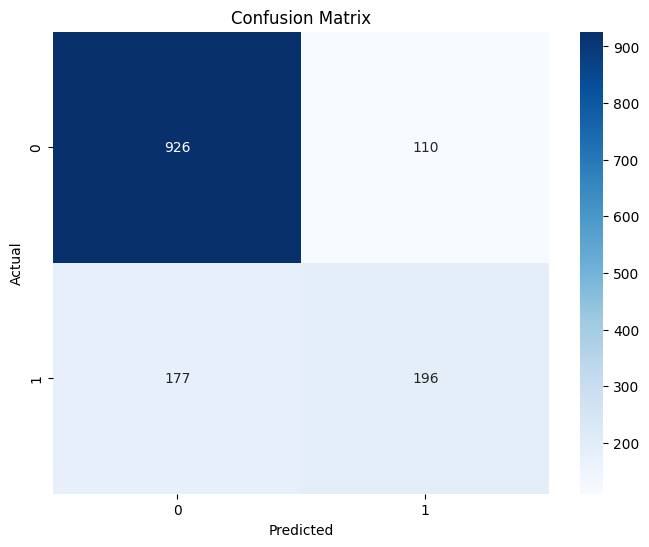

In [55]:
cm = confusion_matrix(y_test, predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
print("\nClassification Report:")
print(classification_report(y_test, predict))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1036
           1       0.64      0.53      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

